# 11 — Cinq modèles PFAS avec HGT **transductif** (graphe unique + masques)

Corrections apportées par rapport aux notebooks 09 et 10 :

1. **Graphe transductif unique** : un seul graphe construit sur *tous* les puits (train+val+test),
   avec des masques `train/val/test`. Les puits de test bénéficient du message passing depuis
   leurs voisins d'entraînement (dans les NB 09/10 les trois graphes étaient disjoints —
   un puits de test n'avait aucun voisin connu).
2. **Localisation réintégrée** (`DROP_LOCATION=False`) : lat/lon/county redeviennent des features
   du nœud `sample`. Le NB 10 avait changé deux choses à la fois (graphe relationnel **et**
   retrait de la localisation), rendant la comparaison impossible.
3. **Sélection et HPO du HGT sur l'AUC de validation** (et non le F1 au seuil argmax),
   pour être aligné avec la métrique de comparaison finale.
4. **Architecture renforcée** : résidus + LayerNorm par couche, jumping knowledge
   (concaténation `[h0 ‖ h1 ‖ … ‖ hL]` au classifieur) — le signal tabulaire brut ne peut
   plus être détruit par le message passing (garantit GNN ≥ MLP en théorie).
5. **Stacking honnête** : le méta-modèle est entraîné sur les prédictions du set de
   **validation** (jamais vues en fit par les modèles de base), plus un ensemble à moyenne
   pondérée optimisée sur validation. Fini les méta-features issues du train re-prédit.
6. **Split par puits optionnel** (`GROUP_SPLIT_BY_WELL`) : évite que des prélèvements du même
   puits (`gm_well_id`) se retrouvent à la fois en train et en test.

Le graphe relationnel reprend celui du NB 10 : kNN spatial `sample↔sample`, hubs `subbasin`,
hubs `geo_cluster` (KMeans ajusté sur le train), nœuds `source` GeoTracker.

In [1]:
# --- Detection de l'environnement ---
import sys, importlib.util, subprocess
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except Exception:
    IN_COLAB = False

def _pip(*pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=False)

if IN_COLAB:
    print("Google Colab detecte — installation des dependances...")
    import torch
    tv = torch.__version__.split("+")[0]
    cu = ("cu" + torch.version.cuda.replace(".", "")) if torch.version.cuda else "cpu"
    print(f"  torch={tv} | backend={cu}")
    _pip("torch_geometric")
    _pip("pyg_lib", "torch_scatter", "torch_sparse",
         "-f", f"https://data.pyg.org/whl/torch-{tv}+{cu}.html")
    _pip("xgboost", "optuna", "shap", "seaborn", "pyarrow", "networkx")
    print("Installation terminee.")
else:
    print("Environnement local — verification des librairies (aucune installation).")
    for m in ["torch", "torch_geometric", "xgboost", "optuna", "shap"]:
        ok = importlib.util.find_spec(m) is not None
        print(f"  {m:16s}: {'OK' if ok else 'MANQUANT'}")

Google Colab detecte — installation des dependances...
  torch=2.11.0 | backend=cu128
Installation terminee.


In [2]:
import warnings, json, pickle, time, os, zipfile
from pathlib import Path
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except Exception:
    IN_COLAB = False
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

from sklearn.model_selection import (train_test_split, StratifiedKFold,
    GroupShuffleSplit, cross_val_score)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.calibration import calibration_curve
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
    ConfusionMatrixDisplay, roc_curve, precision_recall_curve, accuracy_score,
    recall_score, precision_score, balanced_accuracy_score)

import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Repli CPU : passez FORCE_CPU=True si le GPU Colab plante (CUDA device-side assert).
FORCE_CPU = True
if FORCE_CPU:
    os.environ["CUDA_VISIBLE_DEVICES"] = ""
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau
try:
    from torch_geometric.data import HeteroData
    from torch_geometric.nn import HGTConv, Linear as PyGLinear
    TORCH_GEOMETRIC_AVAILABLE = True
except Exception as e:
    TORCH_GEOMETRIC_AVAILABLE = False
    print("PyTorch Geometric indisponible :", e)

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})
print("Imports OK | PyG disponible :", TORCH_GEOMETRIC_AVAILABLE)

Imports OK | PyG disponible : True


In [3]:
# ════════════════════════════════════════════════════════════════════════
#  CONFIGURATION GLOBALE
# ════════════════════════════════════════════════════════════════════════
RANDOM_STATE = 42

# --- Donnees ---
DATA_FILENAME      = "CA-PFAS-ASGWS_v2.parquet"
MISSING_THRESHOLD  = 0.40
DROP_LOCATION      = False   # CORRECTION NB10 : lat/lon/county redeviennent des features
DEV_SUBSAMPLE      = None    # int (ex 5000) pour un test rapide

# --- Split ---
TEST_SIZE = 0.20
VAL_SIZE  = 0.25             # part du reste -> 60/20/20
GROUP_SPLIT_BY_WELL = True   # CORRECTION : aucun puits (gm_well_id) a cheval train/test
                             # False = split aleatoire stratifie (comparabilite NB09/10)

# --- Graphe relationnel TRANSDUCTIF ---
REGION_COL         = "sgma_subbasin_name"
KNN_SPATIAL_K      = 8
USE_SOURCE_NODES   = True
SITES_FILENAME     = "geotracker_pfas_investigation_sites.csv"
SOURCE_RADIUS_KM   = 50.0
SOURCE_KMAX        = 6

# --- Optuna ---
OPTUNA_MODE = "FULL"
_TRIALS = {
    "FAST": {"rf": 8,  "xgb": 10, "hgt": 6,  "fusion": 8},
    "FULL": {"rf": 40, "xgb": 60, "hgt": 25, "fusion": 20},
}[OPTUNA_MODE]
OPTUNA_TIMEOUT = {"FAST": 300, "FULL": 1800}[OPTUNA_MODE]

# --- HGT ---
EPOCHS_HGT     = {"FAST": 60, "FULL": 300}[OPTUNA_MODE]
N_GEO_CLUSTERS = 20

# --- Section finale : evaluation honnete ---
RUN_SPATIAL_CV = True    # CV spatiale par blocs k=8 (long). True pour le rendu final.
SPATIAL_CV_K   = 8

# --- Reglementation EPA 2024 NPDWR ---
EPA2024_MCLS = {"PFOA_ngL": 4.0, "PFOS_ngL": 4.0, "PFNA_ngL": 10.0,
                "PFHxS_ngL": 10.0, "HFPO_DA_ngL": 10.0}
HI_REFS = {"PFNA_ngL": 10.0, "PFHxS_ngL": 10.0, "HFPO_DA_ngL": 10.0, "PFBS_ngL": 2000.0}

np.random.seed(RANDOM_STATE)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
try:
    torch.manual_seed(RANDOM_STATE)
except Exception as _e:
    print("Avertissement CUDA :", _e); device = torch.device("cpu")

OUT_DIR    = Path("outputs_notebook_transductif")
FIG_DIR    = OUT_DIR / "figures"
RES_DIR    = OUT_DIR / "results"
MODELS_DIR = OUT_DIR / "models"
for d in (FIG_DIR, RES_DIR, MODELS_DIR):
    d.mkdir(parents=True, exist_ok=True)

def savefig(fig, name):
    fig.savefig(FIG_DIR / name, dpi=150, bbox_inches="tight")

print(f"Mode Optuna : {OPTUNA_MODE} | trials={_TRIALS} | epochs HGT={EPOCHS_HGT}")
print(f"Split par puits : {GROUP_SPLIT_BY_WELL} | Device : {device}")

Mode Optuna : FULL | trials={'rf': 40, 'xgb': 60, 'hgt': 25, 'fusion': 20} | epochs HGT=300
Split par puits : True | Device : cpu


In [4]:
GITHUB_REPO_RAW = ("https://raw.githubusercontent.com/dnwiloic/pfas-gnn/"
                   "d31351fa9e83b7dda9ea252bdecd51c374d9b8e9/data")

def locate_dataset(filename):
    candidates = [Path(filename), Path("data/processed")/filename,
                  Path("../data/processed")/filename,
                  Path("data/raw/contamination")/filename,
                  Path("../data/raw/contamination")/filename,
                  Path("/content")/filename, Path("/content/drive/MyDrive")/filename]
    for c in candidates:
        if c.exists():
            return c
    # Telechargement automatique depuis GitHub (repo public dnwiloic/pfas-gnn)
    try:
        import urllib.request
        url = f"{GITHUB_REPO_RAW}/{filename}"
        dest = Path(filename)
        print(f"Fichier local introuvable -> telechargement depuis GitHub : {url}")
        urllib.request.urlretrieve(url, dest)
        if dest.exists() and dest.stat().st_size > 0:
            print(f"  OK -> {dest} ({dest.stat().st_size/1e6:.1f} Mo)")
            return dest
    except Exception as e:
        print(f"  Echec du telechargement GitHub : {e}")
    if IN_COLAB:
        from google.colab import files
        print(f"Veuillez televerser '{filename}' :")
        up = files.upload()
        return Path(list(up.keys())[0])
    raise FileNotFoundError(f"{filename} introuvable — placez-le a cote du notebook.")

DATA_PATH = locate_dataset(DATA_FILENAME)
df = pd.read_parquet(DATA_PATH)
if DEV_SUBSAMPLE:
    df = df.sample(n=min(DEV_SUBSAMPLE, len(df)), random_state=RANDOM_STATE).reset_index(drop=True)
    print(f"[DEV] sous-echantillon : {len(df)} lignes")
print(f"Dataset : {df.shape[0]:,} lignes x {df.shape[1]} colonnes  (source: {DATA_PATH})")

Dataset : 46,338 lignes x 217 colonnes  (source: CA-PFAS-ASGWS_v2.parquet)


In [5]:
sites_df = None
if USE_SOURCE_NODES:
    try:
        sp = locate_dataset(SITES_FILENAME)
        sites_df = pd.read_csv(sp).dropna(subset=["latitude", "longitude"]).reset_index(drop=True)
        print(f"Sites GeoTracker charges : {len(sites_df)}  (source: {sp})")
    except Exception as e:
        USE_SOURCE_NODES = False
        print(f"Sites GeoTracker indisponibles -> noeuds 'source' desactives ({e})")
else:
    print("Noeuds 'source' desactives (USE_SOURCE_NODES=False)")

Sites GeoTracker charges : 463  (source: geotracker_pfas_investigation_sites.csv)


In [6]:
def compute_target_epa2024(d):
    exceeded = pd.Series(False, index=d.index)
    for col, mcl in EPA2024_MCLS.items():
        if col in d.columns:
            exceeded |= d[col].fillna(0) > mcl
    hi = sum(d[c].fillna(0) / r for c, r in HI_REFS.items() if c in d.columns)
    exceeded |= hi > 1.0
    return exceeded.astype(int)

df["target"] = compute_target_epa2024(df)
n_pos = int(df["target"].sum()); n_neg = len(df) - n_pos
print(f"Positifs (>= MCL ou HI>1) : {n_pos:,}  ({100*n_pos/len(df):.2f}%)")
print(f"Negatifs (< MCL)          : {n_neg:,}  ({100*n_neg/len(df):.2f}%)")

Positifs (>= MCL ou HI>1) : 21,154  (45.65%)
Negatifs (< MCL)          : 25,184  (54.35%)


In [7]:
# ── Sources de fuite (identiques NB09/10) ───────────────────────────────
LEAK_SUFFIXES      = ("_ngL",)
LEAK_BOOL_SUFFIXES = ("_detected",)
LEAK_PREFIXES      = ("label_",)
LEAK_EXACT = {
    "sum_pfas_ngL", "pfas_class_assignment", "gm_well_id", "collection_date",
    "target", "target_sum_gt70", "gm_dataset_name", "gldas_dist_km",
}
DROP_REDUNDANT = {"dwr_basin", "sgma_basin_name", "sgma_subbasin_name"}

if "collection_date" in df.columns:
    _dt = pd.to_datetime(df["collection_date"], errors="coerce")
    df["year"]   = _dt.dt.year
    df["month"]  = _dt.dt.month
    df["season"] = ((_dt.dt.month % 12) // 3 + 1).astype("float")

_miss = df.isna().mean()
HIGH_MISSING_DROP = set(_miss[_miss > MISSING_THRESHOLD].index)

LOCATION_FEATURES = {"latitude", "longitude", "county", "regional_board",
                     "dwr_region", "sgma_region_office"}
loc_drop = LOCATION_FEATURES if DROP_LOCATION else set()

CATEGORICAL_CANDIDATES = ["county", "regional_board", "dwr_region", "gm_well_category",
                          "sgma_region_office", "nearest_geotracker_type", "soil_texture_class"]
cat_cols = [c for c in CATEGORICAL_CANDIDATES
            if c in df.columns and c not in loc_drop and c not in HIGH_MISSING_DROP]

def _is_leak(c):
    return (any(c.endswith(s) for s in LEAK_SUFFIXES)
            or any(c.endswith(s) for s in LEAK_BOOL_SUFFIXES)
            or any(c.startswith(p) for p in LEAK_PREFIXES)
            or c in LEAK_EXACT)

num_cols = [c for c in df.columns
            if df[c].dtype.kind in ("f", "i", "u")
            and not _is_leak(c) and c not in HIGH_MISSING_DROP
            and c not in DROP_REDUNDANT and c not in loc_drop and c not in cat_cols]

feature_names = num_cols + cat_cols
print(f"Features numeriques : {len(num_cols)} | categorielles : {len(cat_cols)} | TOTAL : {len(feature_names)}")
assert not any(_is_leak(c) for c in feature_names), "FUITE detectee dans les features !"
print("Verification anti-fuite : OK (lat/lon presentes :", "latitude" in feature_names, ")")

Features numeriques : 96 | categorielles : 7 | TOTAL : 103
Verification anti-fuite : OK (lat/lon presentes : True )


## Split et prétraitement

Le prétraitement produit `X_all_proc` / `X_all_sc` sur **l'ordre global du dataset** (imputation
et standardisation ajustées sur le train uniquement). Les modèles tabulaires consomment les
sous-matrices indexées ; le graphe transductif consomme la matrice complète avec des masques.

In [8]:
X = df[feature_names].copy()
y = df["target"].values
idx_all = np.arange(len(df))

if GROUP_SPLIT_BY_WELL and "gm_well_id" in df.columns:
    groups = df["gm_well_id"].astype(str).values
    gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
    idx_tmp, idx_test = next(gss.split(idx_all, y, groups=groups))
    gss2 = GroupShuffleSplit(n_splits=1, test_size=VAL_SIZE, random_state=RANDOM_STATE)
    a, b = next(gss2.split(idx_tmp, y[idx_tmp], groups=groups[idx_tmp]))
    idx_train, idx_val = idx_tmp[a], idx_tmp[b]
    _nw = lambda ix: df["gm_well_id"].iloc[ix].nunique()
    print(f"Split PAR PUITS — puits uniques : train {_nw(idx_train):,} | val {_nw(idx_val):,} | test {_nw(idx_test):,}")
    assert not (set(groups[idx_train]) & set(groups[idx_test])), "un puits est a cheval train/test !"
else:
    idx_tmp, idx_test = train_test_split(idx_all, test_size=TEST_SIZE,
                                         stratify=y, random_state=RANDOM_STATE)
    idx_train, idx_val = train_test_split(idx_tmp, test_size=VAL_SIZE,
                                          stratify=y[idx_tmp], random_state=RANDOM_STATE)
    print("Split aleatoire stratifie (comparabilite NB09/10)")

y_train, y_val, y_test = y[idx_train], y[idx_val], y[idx_test]
print(f"Train: {len(idx_train):,} ({100*y_train.mean():.1f}% +) | "
      f"Val: {len(idx_val):,} ({100*y_val.mean():.1f}% +) | "
      f"Test: {len(idx_test):,} ({100*y_test.mean():.1f}% +)")

# ── Preprocesseur (fit sur train, transform sur TOUT le dataset) ────────
numeric_pipe = Pipeline([("imputer", SimpleImputer(strategy="median"))])
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value",
                               unknown_value=-1, encoded_missing_value=-1)),
])
preprocessor = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols),
], remainder="drop")

preprocessor.fit(X.iloc[idx_train])
X_all_proc = preprocessor.transform(X)
proc_cols = num_cols + cat_cols

scaler = StandardScaler().fit(X_all_proc[idx_train])
X_all_sc = scaler.transform(X_all_proc)

X_train_proc, X_val_proc, X_test_proc = (X_all_proc[i] for i in (idx_train, idx_val, idx_test))

# META pour le graphe (coords + sous-bassin) — ordre global
_meta_cols = ["latitude", "longitude"] + ([REGION_COL] if REGION_COL in df.columns else [])
META_all = df[_meta_cols].reset_index(drop=True)
print(f"X_all_proc {X_all_proc.shape} | META {_meta_cols}")

Split PAR PUITS — puits uniques : train 6,799 | val 2,267 | test 2,267
Train: 27,894 (46.5% +) | Val: 9,264 (45.0% +) | Test: 9,180 (43.8% +)
X_all_proc (46338, 103) | META ['latitude', 'longitude', 'sgma_subbasin_name']


In [9]:
RESULTS = {}

def evaluate(name, y_true, y_pred, y_proba, store=True, show=True):
    m = {"name": name,
         "roc_auc": roc_auc_score(y_true, y_proba),
         "avg_precision": average_precision_score(y_true, y_proba),
         "accuracy": accuracy_score(y_true, y_pred),
         "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
         "precision": precision_score(y_true, y_pred, zero_division=0),
         "recall": recall_score(y_true, y_pred),
         "f1": f1_score(y_true, y_pred)}
    if show:
        print(f"{'─'*52}\n  {name}\n{'─'*52}")
        for k in ["roc_auc","avg_precision","recall","precision","f1","balanced_accuracy","accuracy"]:
            print(f"  {k:20s}: {m[k]:.4f}")
    if store:
        RESULTS[name] = {"metrics": m, "y_pred": np.asarray(y_pred), "y_proba": np.asarray(y_proba)}
    return m

def plot_confusion(name, y_true, y_pred, fname):
    fig, ax = plt.subplots(figsize=(4.3, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, display_labels=["< MCL (0)", ">= MCL (1)"],
        cmap="Blues", ax=ax, colorbar=False)
    ax.set_title(f"Matrice de confusion — {name}")
    plt.tight_layout(); savefig(fig, fname); plt.show()

def optuna_history_fig(study, title, fname, color="steelblue"):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    vals = [t.value for t in study.trials if t.value is not None]
    best = [max(vals[:i+1]) for i in range(len(vals))]
    axes[0].plot(vals, "o", alpha=.4, color=color, ms=5, label="Trial")
    axes[0].plot(best, "-", color="black", lw=2, label="Meilleur cumule")
    axes[0].set(xlabel="Trial", ylabel="Score objectif (AUC val)", title=f"{title} — historique Optuna")
    axes[0].legend(); axes[0].grid(alpha=.3)
    try:
        imp = optuna.importance.get_param_importances(study)
        axes[1].barh(list(imp.keys())[::-1], list(imp.values())[::-1], color=color)
        axes[1].set(xlabel="Importance relative", title="Importance des hyperparametres")
    except Exception:
        axes[1].text(.5, .5, "Pas assez de trials", ha="center", transform=axes[1].transAxes)
    plt.tight_layout(); savefig(fig, fname); plt.show()

scale_pos = (y_train == 0).sum() / max(1, (y_train == 1).sum())
skf5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print("Utilitaires prets. scale_pos_weight =", round(scale_pos, 3))

Utilitaires prets. scale_pos_weight = 1.152


## Modèle 1 — Random Forest (référence tabulaire)

  0%|          | 0/40 [00:00<?, ?it/s]

Meilleur AUC-CV : 0.9804 | params : {'n_estimators': 600, 'max_depth': 30, 'max_features': 0.5, 'min_samples_leaf': 3, 'min_samples_split': 6}


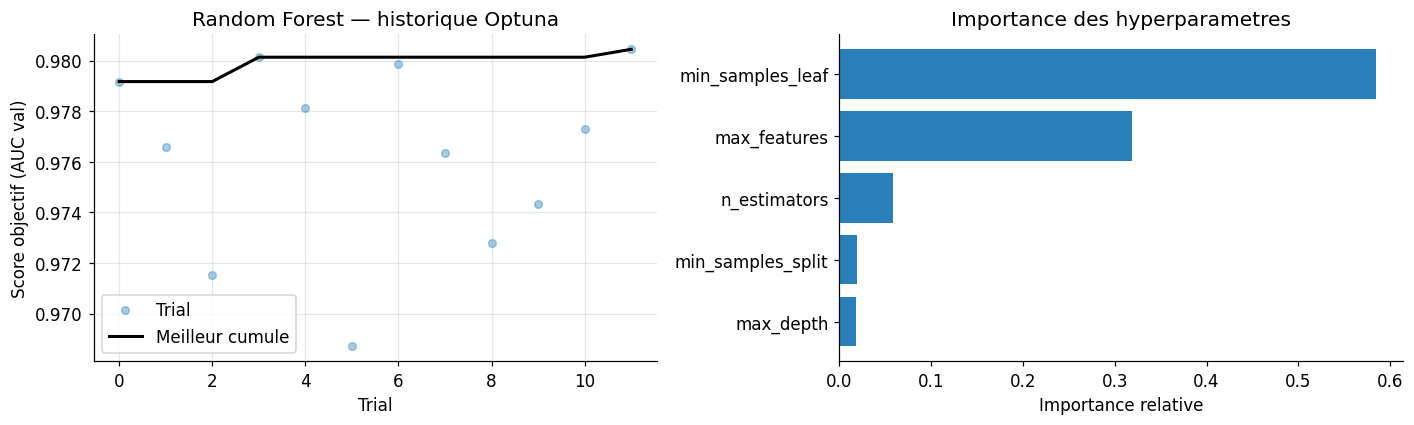

────────────────────────────────────────────────────
  Random Forest
────────────────────────────────────────────────────
  roc_auc             : 0.8910
  avg_precision       : 0.8763
  recall              : 0.7280
  precision           : 0.8589
  f1                  : 0.7881
  balanced_accuracy   : 0.8174
  accuracy            : 0.8284


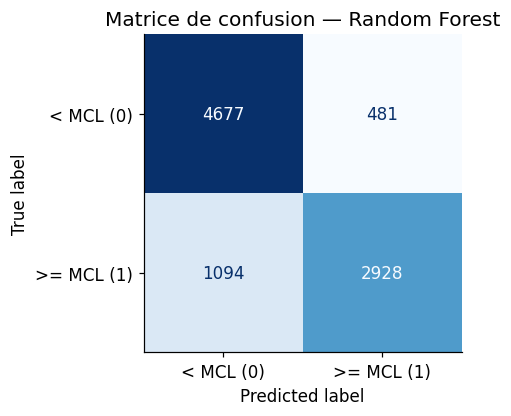

In [10]:
def objective_rf(trial):
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 200, 800, step=100),
        max_depth=trial.suggest_categorical("max_depth", [None, 15, 20, 30]),
        max_features=trial.suggest_categorical("max_features", ["sqrt", "log2", 0.3, 0.5]),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 10),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 15),
        class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE)
    sc = cross_val_score(RandomForestClassifier(**params), X_train_proc, y_train,
                         cv=StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE),
                         scoring="roc_auc", n_jobs=1)
    return sc.mean()

study_rf = optuna.create_study(direction="maximize",
                               sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_rf.enqueue_trial({"n_estimators": 500, "max_depth": None, "max_features": "sqrt",
                        "min_samples_leaf": 2, "min_samples_split": 2})
study_rf.optimize(objective_rf, n_trials=_TRIALS["rf"], timeout=OPTUNA_TIMEOUT, show_progress_bar=True)
print("Meilleur AUC-CV :", round(study_rf.best_value, 4), "| params :", study_rf.best_params)
optuna_history_fig(study_rf, "Random Forest", "fig01_optuna_rf.png", color="#2980b9")

best_rf_params = {**study_rf.best_params, "class_weight": "balanced",
                  "n_jobs": -1, "random_state": RANDOM_STATE}
rf = RandomForestClassifier(**best_rf_params).fit(X_train_proc, y_train)
y_pred_rf  = rf.predict(X_test_proc)
y_proba_rf = rf.predict_proba(X_test_proc)[:, 1]
m_rf = evaluate("Random Forest", y_test, y_pred_rf, y_proba_rf)
plot_confusion("Random Forest", y_test, y_pred_rf, "fig02_rf_confusion.png")

## Modèle 2 — XGBoost (référence tabulaire)

  0%|          | 0/60 [00:00<?, ?it/s]

Meilleur AUC-val : 0.8794 | params : {'n_estimators': 1100, 'learning_rate': 0.06542753299106235, 'max_depth': 9, 'subsample': 0.8086998925784614, 'colsample_bytree': 0.8401522593572472, 'min_child_weight': 6, 'gamma': 0.4507328559480873, 'reg_alpha': 3.2988676431648466e-07, 'reg_lambda': 1.4720361172033253e-06}


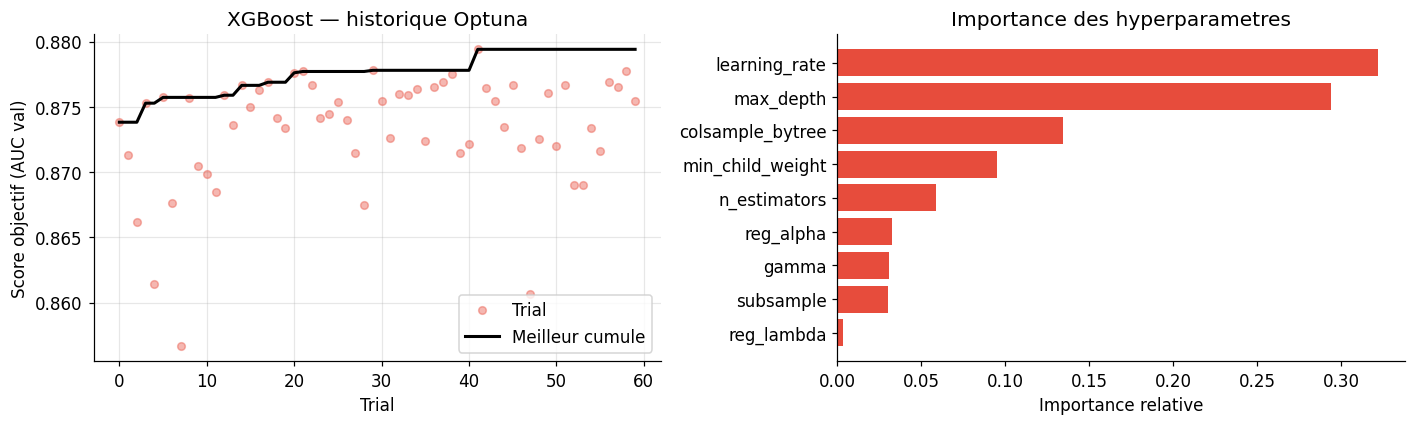

Best iteration : 88
────────────────────────────────────────────────────
  XGBoost
────────────────────────────────────────────────────
  roc_auc             : 0.9059
  avg_precision       : 0.8911
  recall              : 0.7541
  precision           : 0.8484
  f1                  : 0.7985
  balanced_accuracy   : 0.8245
  accuracy            : 0.8332


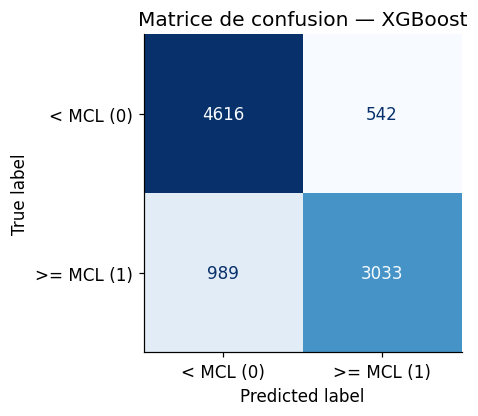

In [11]:
def objective_xgb(trial):
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 200, 2000, step=100),
        learning_rate=trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
        max_depth=trial.suggest_int("max_depth", 3, 12),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.4, 1.0),
        min_child_weight=trial.suggest_int("min_child_weight", 1, 15),
        gamma=trial.suggest_float("gamma", 0.0, 2.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        scale_pos_weight=scale_pos, tree_method="hist", n_jobs=-1,
        random_state=RANDOM_STATE, eval_metric="auc", verbosity=0)
    model = xgb.XGBClassifier(**params, early_stopping_rounds=40)
    model.fit(X_train_proc, y_train, eval_set=[(X_val_proc, y_val)], verbose=False)
    return roc_auc_score(y_val, model.predict_proba(X_val_proc)[:, 1])

study_xgb = optuna.create_study(direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=5))
study_xgb.enqueue_trial({"n_estimators": 1000, "learning_rate": 0.05, "max_depth": 6,
    "subsample": 0.8, "colsample_bytree": 0.8, "min_child_weight": 3, "gamma": 0.1,
    "reg_alpha": 0.1, "reg_lambda": 1.0})
study_xgb.optimize(objective_xgb, n_trials=_TRIALS["xgb"], timeout=OPTUNA_TIMEOUT, show_progress_bar=True)
print("Meilleur AUC-val :", round(study_xgb.best_value, 4), "| params :", study_xgb.best_params)
optuna_history_fig(study_xgb, "XGBoost", "fig03_optuna_xgb.png", color="#e74c3c")

best_xgb_params = {**study_xgb.best_params, "scale_pos_weight": scale_pos,
                   "tree_method": "hist", "n_jobs": -1, "random_state": RANDOM_STATE,
                   "eval_metric": "auc", "verbosity": 0}
xgb_model = xgb.XGBClassifier(**best_xgb_params, early_stopping_rounds=50)
xgb_model.fit(X_train_proc, y_train, eval_set=[(X_val_proc, y_val)], verbose=False)
print(f"Best iteration : {xgb_model.best_iteration}")
y_pred_xgb  = xgb_model.predict(X_test_proc)
y_proba_xgb = xgb_model.predict_proba(X_test_proc)[:, 1]
m_xgb = evaluate("XGBoost", y_test, y_pred_xgb, y_proba_xgb)
plot_confusion("XGBoost", y_test, y_pred_xgb, "fig04_xgb_confusion.png")

## Graphe relationnel **transductif**

Un seul `HeteroData` sur les 100 % des puits. Trois masques booléens sur le nœud `sample`
(`train_mask`, `val_mask`, `test_mask`). La loss n'est calculée que sur `train_mask` — les
labels de val/test ne participent jamais à l'entraînement ; seules leurs **features** et la
**structure** (voisinage) sont visibles, ce qui est le setting transductif standard de la
classification de nœuds. Le KMeans des `geo_cluster` est ajusté sur les coordonnées du train.

In [12]:
from sklearn.neighbors import NearestNeighbors, BallTree

if TORCH_GEOMETRIC_AVAILABLE:
    LATLON_META = ["latitude", "longitude"]
    coords_all = META_all[LATLON_META].values.astype("float32")

    # ── Registre SOURCE (sites GeoTracker) ──────────────────────────────
    SOURCE_X, SRC_TREE, N_SITES = None, None, 0
    if USE_SOURCE_NODES and sites_df is not None:
        _sc = sites_df[["latitude", "longitude"]].values.astype("float64")
        SRC_TREE = BallTree(np.radians(_sc), metric="haversine")
        _st = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)\
              .fit_transform(sites_df[["site_type"]].astype(str)).ravel() if "site_type" in sites_df else np.zeros(len(_sc))
        _z = lambda a: (np.asarray(a, float) - np.asarray(a, float).mean()) / (np.asarray(a, float).std() + 1e-9)
        SOURCE_X = np.column_stack([_z(_sc[:, 0]), _z(_sc[:, 1]), _z(_st)]).astype("float32")
        N_SITES = len(_sc)
        print(f"Noeuds source : {N_SITES} sites GeoTracker | rayon {SOURCE_RADIUS_KM} km | k_max {SOURCE_KMAX}")

    R_RAD = SOURCE_RADIUS_KM / 6371.0

    def source_edges(coords):
        d_, idx = SRC_TREE.query(np.radians(coords), k=min(SOURCE_KMAX, N_SITES))
        s, t = [], []
        for i in range(len(coords)):
            keep = [idx[i, 0]]
            for j in range(1, idx.shape[1]):
                if d_[i, j] <= R_RAD:
                    keep.append(idx[i, j])
            for k in keep:
                s.append(i); t.append(int(k))
        return np.array(s), np.array(t)

    def region_nodes(meta):
        reg = meta[REGION_COL].fillna("UNKNOWN").astype(str).values if REGION_COL in meta else np.array(["ALL"]*len(meta))
        cats, inv = np.unique(reg, return_inverse=True)
        feats = np.zeros((len(cats), 3), "float32")
        lat, lon = meta["latitude"].values, meta["longitude"].values
        for k in range(len(cats)):
            m = inv == k
            feats[k] = [lat[m].mean(), lon[m].mean(), np.log1p(m.sum())]
        feats = (feats - feats.mean(0)) / (feats.std(0) + 1e-9)
        return inv.astype("int64"), feats

    def knn_edges(coords, k):
        k = min(k + 1, len(coords)); nn_ = NearestNeighbors(n_neighbors=k).fit(coords)
        _, idx = nn_.kneighbors(coords)
        s = np.repeat(np.arange(len(coords)), idx.shape[1] - 1); d_ = idx[:, 1:].reshape(-1)
        e = np.stack([s, d_]); return np.concatenate([e, e[::-1]], 1)

    # ── UN SEUL graphe + masques ────────────────────────────────────────
    data = HeteroData(); n = len(df)
    data["sample"].x = torch.FloatTensor(X_all_sc)
    data["sample"].y = torch.LongTensor(y)
    for name_, idx_ in [("train_mask", idx_train), ("val_mask", idx_val), ("test_mask", idx_test)]:
        m = torch.zeros(n, dtype=torch.bool); m[idx_] = True
        data["sample"][name_] = m
    sr = np.arange(n)
    if SOURCE_X is not None:
        data["source"].x = torch.FloatTensor(SOURCE_X)
        ss, st = source_edges(coords_all)
        data["sample", "near_source", "source"].edge_index = torch.tensor(np.stack([ss, st]), dtype=torch.long)
        data["source", "source_of", "sample"].edge_index   = torch.tensor(np.stack([st, ss]), dtype=torch.long)
    inv, rfeat = region_nodes(META_all)
    data["subbasin"].x = torch.FloatTensor(rfeat)
    data["sample", "in_basin", "subbasin"].edge_index = torch.tensor(np.stack([sr, inv]), dtype=torch.long)
    data["subbasin", "basin_of", "sample"].edge_index = torch.tensor(np.stack([inv, sr]), dtype=torch.long)
    geo_km = KMeans(min(N_GEO_CLUSTERS, max(2, len(idx_train)//50)),
                    random_state=RANDOM_STATE, n_init=10).fit(coords_all[idx_train])
    lab = geo_km.predict(coords_all)
    data["geo_cluster"].x = torch.FloatTensor(geo_km.cluster_centers_.astype("float32"))
    data["sample", "located_in", "geo_cluster"].edge_index = torch.tensor(np.stack([sr, lab]), dtype=torch.long)
    data["geo_cluster", "contains", "sample"].edge_index   = torch.tensor(np.stack([lab, sr]), dtype=torch.long)
    if KNN_SPATIAL_K and KNN_SPATIAL_K > 0:
        data["sample", "near_geo", "sample"].edge_index = torch.tensor(knn_edges(coords_all, KNN_SPATIAL_K), dtype=torch.long)

    print("\nTypes de noeuds :", list(data.node_types))
    for a, b, c in data.edge_types:
        print(f"  {a} -[{b}]-> {c}: {data[a, b, c].edge_index.shape[1]:,} aretes")
    # part des voisins kNN d'un puits test qui sont des puits train (le gain transductif)
    ei = data["sample", "near_geo", "sample"].edge_index.numpy()
    tm = data["sample"].test_mask.numpy(); trm = data["sample"].train_mask.numpy()
    from_test = tm[ei[0]]
    print(f"\nAretes kNN partant d'un puits TEST : {from_test.sum():,} "
          f"dont {100*trm[ei[1]][from_test].mean():.1f}% pointent vers un puits TRAIN "
          f"(0% dans les NB 09/10 : graphes disjoints)")

Noeuds source : 463 sites GeoTracker | rayon 50.0 km | k_max 6

Types de noeuds : ['sample', 'source', 'subbasin', 'geo_cluster']
  sample -[near_source]-> source: 241,580 aretes
  source -[source_of]-> sample: 241,580 aretes
  sample -[in_basin]-> subbasin: 46,338 aretes
  subbasin -[basin_of]-> sample: 46,338 aretes
  sample -[located_in]-> geo_cluster: 46,338 aretes
  geo_cluster -[contains]-> sample: 46,338 aretes
  sample -[near_geo]-> sample: 741,408 aretes

Aretes kNN partant d'un puits TEST : 147,558 dont 17.3% pointent vers un puits TRAIN (0% dans les NB 09/10 : graphes disjoints)


## Modèle 3 — HGT transductif (résidus + LayerNorm + jumping knowledge)

Le classifieur reçoit `[h0 ‖ h1 ‖ … ‖ hL]` du nœud `sample` : `h0` est la projection des
features brutes (le signal tabulaire ne peut pas être perdu), les couches suivantes ajoutent
l'information de voisinage.

In [13]:
class HGT_Classifier(nn.Module):
    def __init__(self, metadata, hidden_channels=64, out_channels=2,
                 num_heads=4, num_layers=2, dropout=0.3):
        super().__init__()
        self.lin_dict = nn.ModuleDict({nt: PyGLinear(-1, hidden_channels) for nt in metadata[0]})
        self.convs = nn.ModuleList([
            HGTConv(hidden_channels, hidden_channels, metadata, heads=num_heads)
            for _ in range(num_layers)])
        self.norms = nn.ModuleList([
            nn.ModuleDict({nt: nn.LayerNorm(hidden_channels) for nt in metadata[0]})
            for _ in range(num_layers)])
        jk_dim = hidden_channels * (num_layers + 1)
        self.classifier = nn.Sequential(
            nn.Linear(jk_dim, hidden_channels), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_channels, out_channels))

    def forward(self, x_dict, edge_index_dict, return_embeddings=False):
        x_dict = {nt: self.lin_dict[nt](x).relu() for nt, x in x_dict.items()}
        outs = [x_dict["sample"]]
        for conv, norm in zip(self.convs, self.norms):
            upd = conv(x_dict, edge_index_dict)
            x_dict = {nt: norm[nt](x + upd[nt]) if upd.get(nt) is not None else x
                      for nt, x in x_dict.items()}
            outs.append(x_dict["sample"])
        emb = torch.cat(outs, dim=-1)
        return emb if return_embeddings else self.classifier(emb)

def graph_tensors(d):
    xd = {nt: d[nt].x.to(device) for nt in d.node_types}
    ed = {et: d[et].edge_index.to(device) for et in d.edge_types}
    return xd, ed

if TORCH_GEOMETRIC_AVAILABLE:
    metadata = data.metadata()
    _m0 = HGT_Classifier(metadata).to(device)
    with torch.no_grad():
        _xd, _ed = graph_tensors(data); _ = _m0(_xd, _ed)
    print(f"HGT transductif initialise — {sum(p.numel() for p in _m0.parameters()):,} parametres")

HGT transductif initialise — 182,722 parametres


In [14]:
def augment_graph(xd, ed, noise=0.01, drop=0.1):
    xa = {nt: x + noise * torch.randn_like(x) for nt, x in xd.items()}
    ea = {}
    for et, ei in ed.items():
        keep = (torch.rand(ei.size(1), device=ei.device) > drop).nonzero(as_tuple=True)[0]
        ea[et] = ei if keep.numel() == 0 else ei[:, keep]
    return xa, ea

def train_hgt(model, d, epochs=120, lr=3e-3, weight_decay=1e-5,
              augment=True, noise=0.01, drop=0.1, verbose=True):
    # CORRECTION : selection du modele et scheduler pilotes par l'AUC de validation.
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    xd, ed = graph_tensors(d); yy = d["sample"].y.to(device)
    tm = d["sample"].train_mask.to(device); vm = d["sample"].val_mask.to(device)
    cc = np.bincount(yy[tm].cpu().numpy(), minlength=2)
    cw = torch.FloatTensor([1.0/max(1, c) for c in cc]).to(device); cw = cw / cw.sum()
    crit = nn.CrossEntropyLoss(weight=cw)
    sch = ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=10)
    yv = yy[vm].cpu().numpy()
    best, best_state = 0.0, None
    h = {"train_loss": [], "val_auc": [], "val_f1": []}
    for ep in range(1, epochs+1):
        model.train(); opt.zero_grad()
        xa, ea = augment_graph(xd, ed, noise, drop) if augment else (xd, ed)
        out = model(xa, ea)
        loss = crit(out[tm], yy[tm]); loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            proba = F.softmax(model(xd, ed), dim=1)[:, 1]
            pv = proba[vm].cpu().numpy()
            vauc = roc_auc_score(yv, pv)
            vf1 = f1_score(yv, (pv > 0.5).astype(int))
        sch.step(vauc)
        h["train_loss"].append(loss.item()); h["val_auc"].append(vauc); h["val_f1"].append(vf1)
        if vauc > best:
            best = vauc; best_state = {k: v.clone() for k, v in model.state_dict().items()}
        if verbose and (ep % 10 == 0 or ep == 1):
            print(f"  epoch {ep:3d}/{epochs} | loss {loss:.4f} | val_auc {vauc:.4f} | val_f1 {vf1:.4f}")
    if best_state:
        model.load_state_dict(best_state)
    if verbose:
        print(f"Termine — meilleur val AUC : {best:.4f}")
    return model, h

  0%|          | 0/25 [00:00<?, ?it/s]

Meilleurs params HGT : {'hidden_channels': 128, 'num_heads': 4, 'num_layers': 2, 'dropout': 0.3, 'lr': 0.003, 'weight_decay': 1e-05}


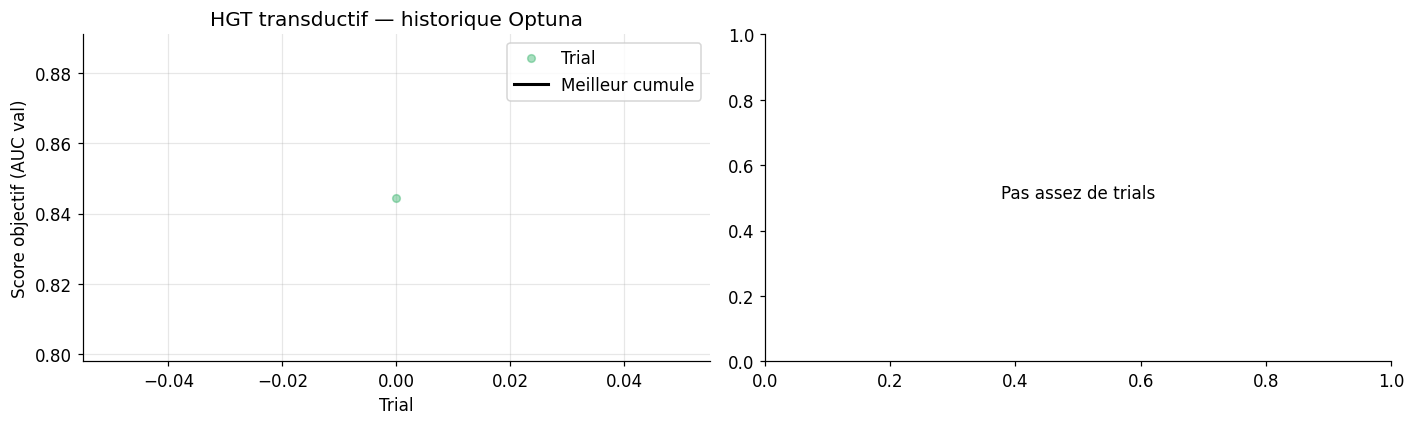

In [15]:
if TORCH_GEOMETRIC_AVAILABLE:
    def objective_hgt(trial):
        m = HGT_Classifier(metadata,
            hidden_channels=trial.suggest_categorical("hidden_channels", [64, 128, 256]),
            num_heads=trial.suggest_categorical("num_heads", [2, 4]),
            num_layers=trial.suggest_int("num_layers", 1, 3),
            dropout=trial.suggest_float("dropout", 0.1, 0.5)).to(device)
        _, h = train_hgt(m, data, epochs=max(40, EPOCHS_HGT//3),
                         lr=trial.suggest_float("lr", 1e-4, 1e-2, log=True),
                         weight_decay=trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True),
                         verbose=False)
        return max(h["val_auc"])
    study_hgt = optuna.create_study(direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study_hgt.enqueue_trial({"hidden_channels": 128, "num_heads": 4, "num_layers": 2,
                             "dropout": 0.3, "lr": 3e-3, "weight_decay": 1e-5})
    study_hgt.optimize(objective_hgt, n_trials=_TRIALS["hgt"], timeout=OPTUNA_TIMEOUT, show_progress_bar=True)
    bp = study_hgt.best_params
    print("Meilleurs params HGT :", bp)
    optuna_history_fig(study_hgt, "HGT transductif", "fig05_optuna_hgt.png", color="#27ae60")

  epoch   1/300 | loss 0.7415 | val_auc 0.6125 | val_f1 0.0000
  epoch  10/300 | loss 0.6242 | val_auc 0.6944 | val_f1 0.6558
  epoch  20/300 | loss 0.5597 | val_auc 0.7522 | val_f1 0.6804
  epoch  30/300 | loss 0.4866 | val_auc 0.8060 | val_f1 0.7233
  epoch  40/300 | loss 0.4329 | val_auc 0.8086 | val_f1 0.7026
  epoch  50/300 | loss 0.3968 | val_auc 0.8163 | val_f1 0.7037
  epoch  60/300 | loss 0.3595 | val_auc 0.8197 | val_f1 0.7295
  epoch  70/300 | loss 0.3345 | val_auc 0.8119 | val_f1 0.7141
  epoch  80/300 | loss 0.3042 | val_auc 0.8141 | val_f1 0.7089
  epoch  90/300 | loss 0.2856 | val_auc 0.8166 | val_f1 0.7153
  epoch 100/300 | loss 0.2813 | val_auc 0.8170 | val_f1 0.7240
  epoch 110/300 | loss 0.2740 | val_auc 0.8162 | val_f1 0.7223
  epoch 120/300 | loss 0.2739 | val_auc 0.8171 | val_f1 0.7224
  epoch 130/300 | loss 0.2734 | val_auc 0.8168 | val_f1 0.7238
  epoch 140/300 | loss 0.2739 | val_auc 0.8169 | val_f1 0.7249
  epoch 150/300 | loss 0.2732 | val_auc 0.8167 | val_f1

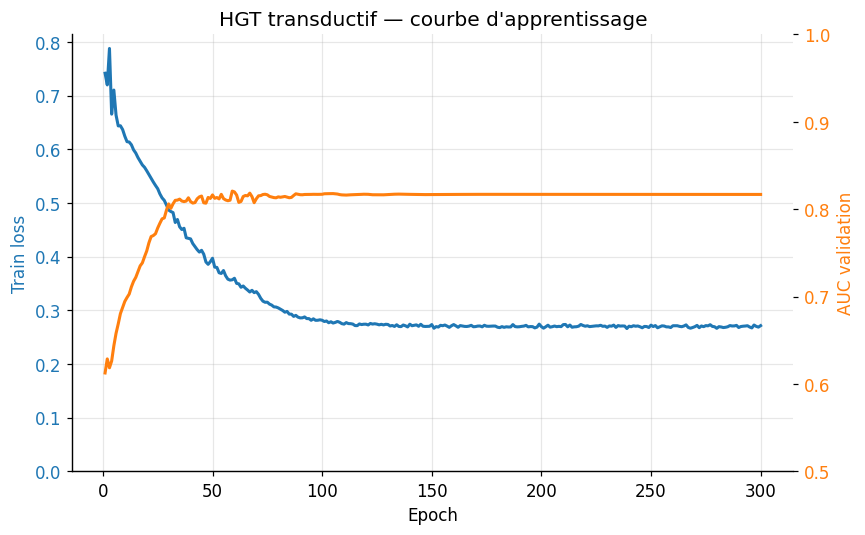

In [16]:
if TORCH_GEOMETRIC_AVAILABLE:
    hgt_model = HGT_Classifier(metadata, hidden_channels=bp["hidden_channels"],
        num_heads=bp["num_heads"], num_layers=bp["num_layers"], dropout=bp["dropout"]).to(device)
    with torch.no_grad():
        _xd, _ed = graph_tensors(data); _ = hgt_model(_xd, _ed)
    hgt_model, hgt_hist = train_hgt(hgt_model, data, epochs=EPOCHS_HGT,
        lr=bp["lr"], weight_decay=bp["weight_decay"], verbose=True)

    ep = range(1, len(hgt_hist["train_loss"])+1)
    fig, ax1 = plt.subplots(figsize=(8, 5))
    ax1.plot(ep, hgt_hist["train_loss"], color="tab:blue", lw=2, label="Train loss")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Train loss", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue"); ax1.grid(alpha=.3); ax1.set_ylim(bottom=0)
    ax2 = ax1.twinx(); ax2.plot(ep, hgt_hist["val_auc"], color="tab:orange", lw=2, label="Val AUC")
    ax2.set_ylabel("AUC validation", color="tab:orange"); ax2.tick_params(axis="y", labelcolor="tab:orange")
    ax2.set_ylim(0.5, 1.0); ax1.set_title("HGT transductif — courbe d'apprentissage")
    plt.tight_layout(); savefig(fig, "fig06_hgt_learning_curve.png"); plt.show()

────────────────────────────────────────────────────
  HGT transductif
────────────────────────────────────────────────────
  roc_auc             : 0.8425
  avg_precision       : 0.8131
  recall              : 0.7887
  precision           : 0.7254
  f1                  : 0.7557
  balanced_accuracy   : 0.7779
  accuracy            : 0.7766


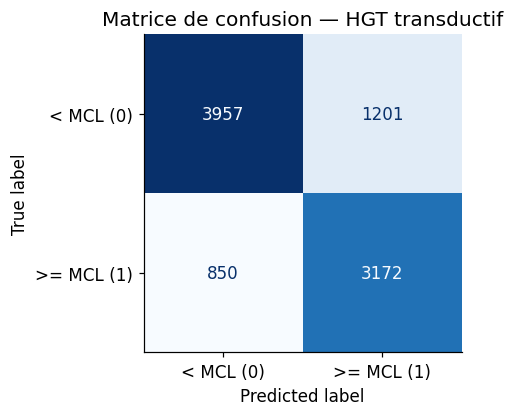

In [17]:
if TORCH_GEOMETRIC_AVAILABLE:
    hgt_model.eval()
    with torch.no_grad():
        xd, ed = graph_tensors(data)
        proba_all = F.softmax(hgt_model(xd, ed), dim=1)[:, 1].cpu().numpy()
    y_proba_hgt = proba_all[idx_test]
    y_pred_hgt  = (y_proba_hgt > 0.5).astype(int)
    m_hgt = evaluate("HGT transductif", y_test, y_pred_hgt, y_proba_hgt)
    plot_confusion("HGT transductif", y_test, y_pred_hgt, "fig07_hgt_confusion.png")

## Modèle 4 — Embedding Fusion (features + embeddings HGT → XGBoost)

Les embeddings viennent maintenant du **même graphe** pour train/val/test (plus de décalage
de densité kNN entre splits). PCA ajustée sur les lignes d'entraînement uniquement.

Embeddings HGT 384D -> PCA 48D (variance 95.1%)


  0%|          | 0/20 [00:00<?, ?it/s]

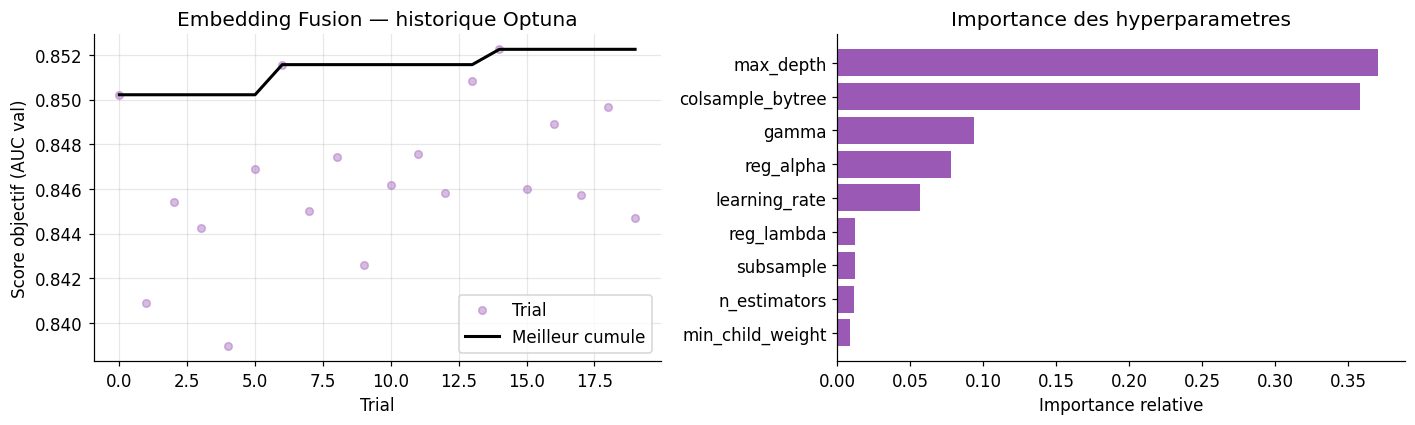

────────────────────────────────────────────────────
  Embedding Fusion
────────────────────────────────────────────────────
  roc_auc             : 0.8808
  avg_precision       : 0.8657
  recall              : 0.7529
  precision           : 0.8149
  f1                  : 0.7826
  balanced_accuracy   : 0.8097
  accuracy            : 0.8168


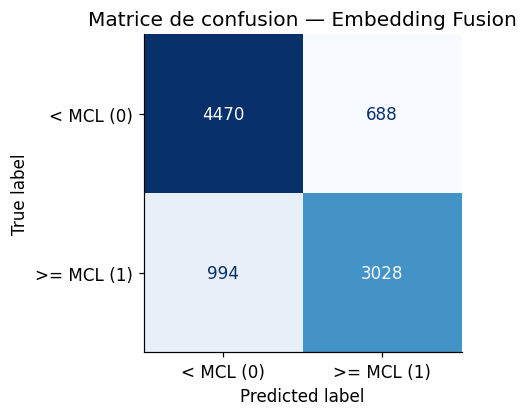

In [18]:
if TORCH_GEOMETRIC_AVAILABLE:
    with torch.no_grad():
        emb_all = hgt_model(xd, ed, return_embeddings=True).cpu().numpy()
    pca_fus = PCA(n_components=0.95, random_state=RANDOM_STATE).fit(emb_all[idx_train])
    emb_p = pca_fus.transform(emb_all)
    n_emb = emb_p.shape[1]
    print(f"Embeddings HGT {emb_all.shape[1]}D -> PCA {n_emb}D "
          f"(variance {pca_fus.explained_variance_ratio_.sum():.1%})")

    X_fus = np.concatenate([X_all_proc, emb_p], axis=1)
    Xtr_fus, Xva_fus, Xte_fus = (X_fus[i] for i in (idx_train, idx_val, idx_test))
    fusion_names = proc_cols + [f"HGT_emb_{j}" for j in range(n_emb)]

    def objective_fusion(trial):
        p = dict(n_estimators=trial.suggest_int("n_estimators", 150, 800),
                 max_depth=trial.suggest_int("max_depth", 3, 12),
                 learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
                 subsample=trial.suggest_float("subsample", 0.5, 1.0),
                 colsample_bytree=trial.suggest_float("colsample_bytree", 0.4, 1.0),
                 min_child_weight=trial.suggest_int("min_child_weight", 1, 10),
                 gamma=trial.suggest_float("gamma", 0.0, 1.0),
                 reg_alpha=trial.suggest_float("reg_alpha", 1e-4, 1.0, log=True),
                 reg_lambda=trial.suggest_float("reg_lambda", 1e-4, 2.0, log=True),
                 scale_pos_weight=scale_pos, tree_method="hist",
                 random_state=RANDOM_STATE, eval_metric="auc", verbosity=0)
        c = xgb.XGBClassifier(**p, early_stopping_rounds=40)
        c.fit(Xtr_fus, y_train, eval_set=[(Xva_fus, y_val)], verbose=False)
        return roc_auc_score(y_val, c.predict_proba(Xva_fus)[:, 1])

    study_fus = optuna.create_study(direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study_fus.optimize(objective_fusion, n_trials=_TRIALS["fusion"], timeout=OPTUNA_TIMEOUT, show_progress_bar=True)
    optuna_history_fig(study_fus, "Embedding Fusion", "fig08_optuna_fusion.png", color="#9b59b6")

    p_fus = {**study_fus.best_params, "scale_pos_weight": scale_pos, "tree_method": "hist",
             "random_state": RANDOM_STATE, "eval_metric": "auc", "verbosity": 0}
    xgb_fusion = xgb.XGBClassifier(**p_fus, early_stopping_rounds=50)
    xgb_fusion.fit(Xtr_fus, y_train, eval_set=[(Xva_fus, y_val)], verbose=False)
    y_pred_fus  = xgb_fusion.predict(Xte_fus)
    y_proba_fus = xgb_fusion.predict_proba(Xte_fus)[:, 1]
    m_fus = evaluate("Embedding Fusion", y_test, y_pred_fus, y_proba_fus)
    plot_confusion("Embedding Fusion", y_test, y_pred_fus, "fig09_fusion_confusion.png")

## Modèle 5 — Stacking honnête (méta-modèle ajusté sur la validation)

Dans les NB 09/10, les méta-features étaient les prédictions **sur le train** de modèles
entraînés sur ce même train (RF quasi parfait → distribution train ≠ test pour le méta-modèle).
Ici : régression logistique sur les probabilités val (jamais utilisées en fit par les modèles
de base), plus une moyenne pondérée dont les poids sont optimisés sur val.

Correlation des predictions test (RF/XGB/HGT) :
        RF    XGB    HGT
RF   1.000  0.962  0.778
XGB  0.962  1.000  0.828
HGT  0.778  0.828  1.000

Poids du meta-modele (RF, XGB, HGT) : [0.119 0.644 0.044]
────────────────────────────────────────────────────
  Stacking
────────────────────────────────────────────────────
  roc_auc             : 0.9061
  avg_precision       : 0.8899
  recall              : 0.7548
  precision           : 0.8504
  f1                  : 0.7998
  balanced_accuracy   : 0.8257
  accuracy            : 0.8344


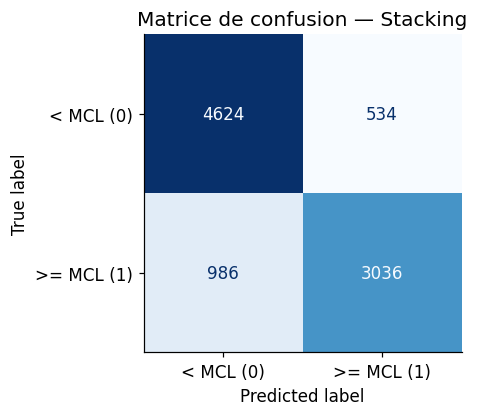


Moyenne ponderee (poids val [0.2  0.75 0.05]) — AUC test : 0.9058


In [19]:
if TORCH_GEOMETRIC_AVAILABLE:
    P_val  = np.column_stack([rf.predict_proba(X_val_proc)[:, 1],
                              xgb_model.predict_proba(X_val_proc)[:, 1],
                              proba_all[idx_val]])
    P_test = np.column_stack([y_proba_rf, y_proba_xgb, y_proba_hgt])

    corr = np.corrcoef(P_test.T)
    print("Correlation des predictions test (RF/XGB/HGT) :")
    print(pd.DataFrame(corr, index=["RF","XGB","HGT"], columns=["RF","XGB","HGT"]).round(3).to_string())

    # (a) meta-modele : regression logistique sur logits
    eps = 1e-6
    logit = lambda p: np.log((p + eps) / (1 - p + eps))
    meta_lr = LogisticRegression(max_iter=1000).fit(logit(P_val), y_val)
    y_proba_stk = meta_lr.predict_proba(logit(P_test))[:, 1]
    y_pred_stk = (y_proba_stk > 0.5).astype(int)
    print("\nPoids du meta-modele (RF, XGB, HGT) :", np.round(meta_lr.coef_[0], 3))
    m_stk = evaluate("Stacking", y_test, y_pred_stk, y_proba_stk)
    plot_confusion("Stacking", y_test, y_pred_stk, "fig10_stacking_confusion.png")

    # (b) reference : moyenne ponderee optimisee sur val (grille simplex)
    best_w, best_auc = None, 0
    for w1 in np.linspace(0, 1, 21):
        for w2 in np.linspace(0, 1 - w1, int(21*(1-w1))+1):
            w = np.array([w1, w2, 1 - w1 - w2])
            auc = roc_auc_score(y_val, P_val @ w)
            if auc > best_auc:
                best_auc, best_w = auc, w
    print(f"\nMoyenne ponderee (poids val {np.round(best_w,2)}) — "
          f"AUC test : {roc_auc_score(y_test, P_test @ best_w):.4f}")

## Comparaison finale

                  ROC-AUC      AP  Rappel  Precision      F1  Bal.Acc  Accuracy
Modele                                                                         
HGT transductif    0.8425  0.8131  0.7887     0.7254  0.7557   0.7779    0.7766
Random Forest      0.8910  0.8763  0.7280     0.8589  0.7881   0.8174    0.8284
XGBoost            0.9059  0.8911  0.7541     0.8484  0.7985   0.8245    0.8332
Embedding Fusion   0.8808  0.8657  0.7529     0.8149  0.7826   0.8097    0.8168
Stacking           0.9061  0.8899  0.7548     0.8504  0.7998   0.8257    0.8344

Meilleur modele (AUC) : Stacking  (AUC=0.9061)


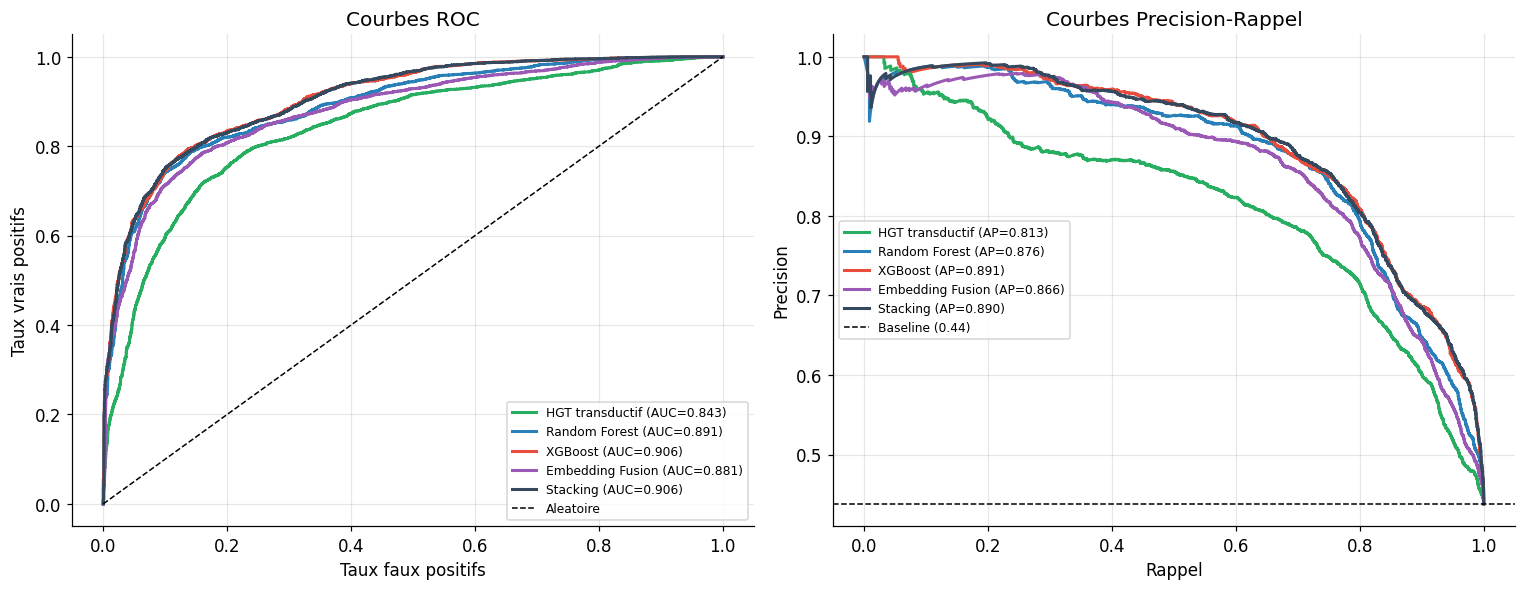

In [20]:
ORDER = ["HGT transductif", "Random Forest", "XGBoost", "Embedding Fusion", "Stacking"]
ORDER = [m for m in ORDER if m in RESULTS]
COLORS = {"HGT transductif": "#27ae60", "Random Forest": "#2980b9", "XGBoost": "#e74c3c",
          "Embedding Fusion": "#9b59b6", "Stacking": "#34495e"}

comp = pd.DataFrame([{
    "Modele": m,
    "ROC-AUC": RESULTS[m]["metrics"]["roc_auc"],
    "AP": RESULTS[m]["metrics"]["avg_precision"],
    "Rappel": RESULTS[m]["metrics"]["recall"],
    "Precision": RESULTS[m]["metrics"]["precision"],
    "F1": RESULTS[m]["metrics"]["f1"],
    "Bal.Acc": RESULTS[m]["metrics"]["balanced_accuracy"],
    "Accuracy": RESULTS[m]["metrics"]["accuracy"],
} for m in ORDER]).set_index("Modele")
comp.to_csv(RES_DIR / "comparaison_modeles.csv")
print(comp.round(4).to_string())
best = comp["ROC-AUC"].idxmax()
print(f"\nMeilleur modele (AUC) : {best}  (AUC={comp.loc[best,'ROC-AUC']:.4f})")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))
prev = y_test.mean()
for m in ORDER:
    pr = RESULTS[m]["y_proba"]; c = COLORS[m]
    fpr, tpr, _ = roc_curve(y_test, pr)
    ax1.plot(fpr, tpr, lw=2, color=c, label=f"{m} (AUC={RESULTS[m]['metrics']['roc_auc']:.3f})")
    p, r, _ = precision_recall_curve(y_test, pr)
    ax2.plot(r, p, lw=2, color=c, label=f"{m} (AP={RESULTS[m]['metrics']['avg_precision']:.3f})")
ax1.plot([0, 1], [0, 1], "k--", lw=1, label="Aleatoire")
ax2.axhline(prev, color="k", ls="--", lw=1, label=f"Baseline ({prev:.2f})")
ax1.set(xlabel="Taux faux positifs", ylabel="Taux vrais positifs", title="Courbes ROC")
ax2.set(xlabel="Rappel", ylabel="Precision", title="Courbes Precision-Rappel")
ax1.legend(fontsize=8); ax2.legend(fontsize=8); ax1.grid(alpha=.3); ax2.grid(alpha=.3)
plt.tight_layout(); savefig(fig, "fig11_roc_pr_all.png"); plt.show()

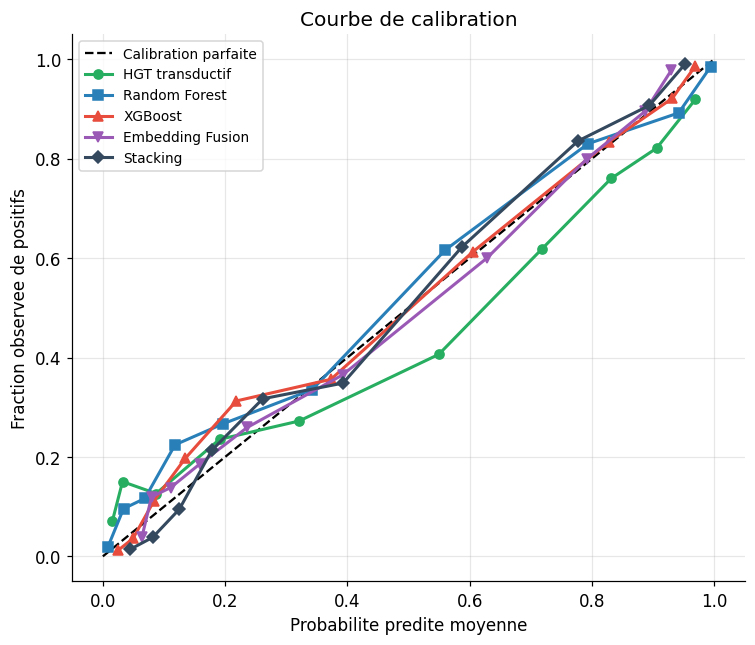

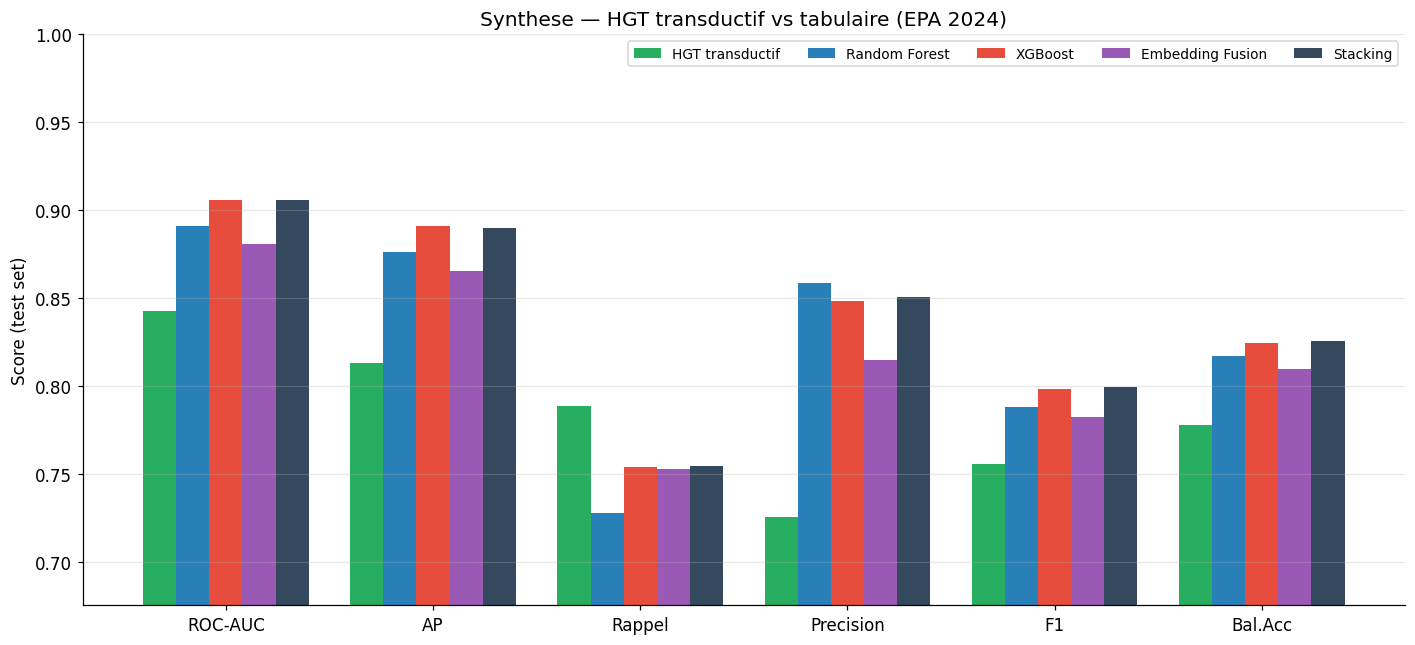

In [21]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], "k--", label="Calibration parfaite")
for m, mk in zip(ORDER, ["o-", "s-", "^-", "v-", "D-"]):
    fr, mp = calibration_curve(y_test, RESULTS[m]["y_proba"], n_bins=10, strategy="quantile")
    ax.plot(mp, fr, mk, color=COLORS[m], lw=2, label=m)
ax.set(xlabel="Probabilite predite moyenne", ylabel="Fraction observee de positifs",
       title="Courbe de calibration")
ax.legend(fontsize=9); ax.grid(alpha=.3)
plt.tight_layout(); savefig(fig, "fig12_calibration_all.png"); plt.show()

metrics = ["roc_auc", "avg_precision", "recall", "precision", "f1", "balanced_accuracy"]
labels = ["ROC-AUC", "AP", "Rappel", "Precision", "F1", "Bal.Acc"]
x = np.arange(len(labels)); w = 0.8 / len(ORDER)
fig, ax = plt.subplots(figsize=(13, 6))
for i, m in enumerate(ORDER):
    vals = [RESULTS[m]["metrics"][k] for k in metrics]
    ax.bar(x + i*w - 0.4 + w/2, vals, w, label=m, color=COLORS[m])
allv = [RESULTS[m]["metrics"][k] for m in ORDER for k in metrics]
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylim(max(0, min(allv) - 0.05), 1.0)
ax.set_ylabel("Score (test set)"); ax.set_title("Synthese — HGT transductif vs tabulaire (EPA 2024)")
ax.legend(fontsize=9, ncol=len(ORDER)); ax.grid(axis="y", alpha=.3)
plt.tight_layout(); savefig(fig, "fig13_dashboard.png"); plt.show()

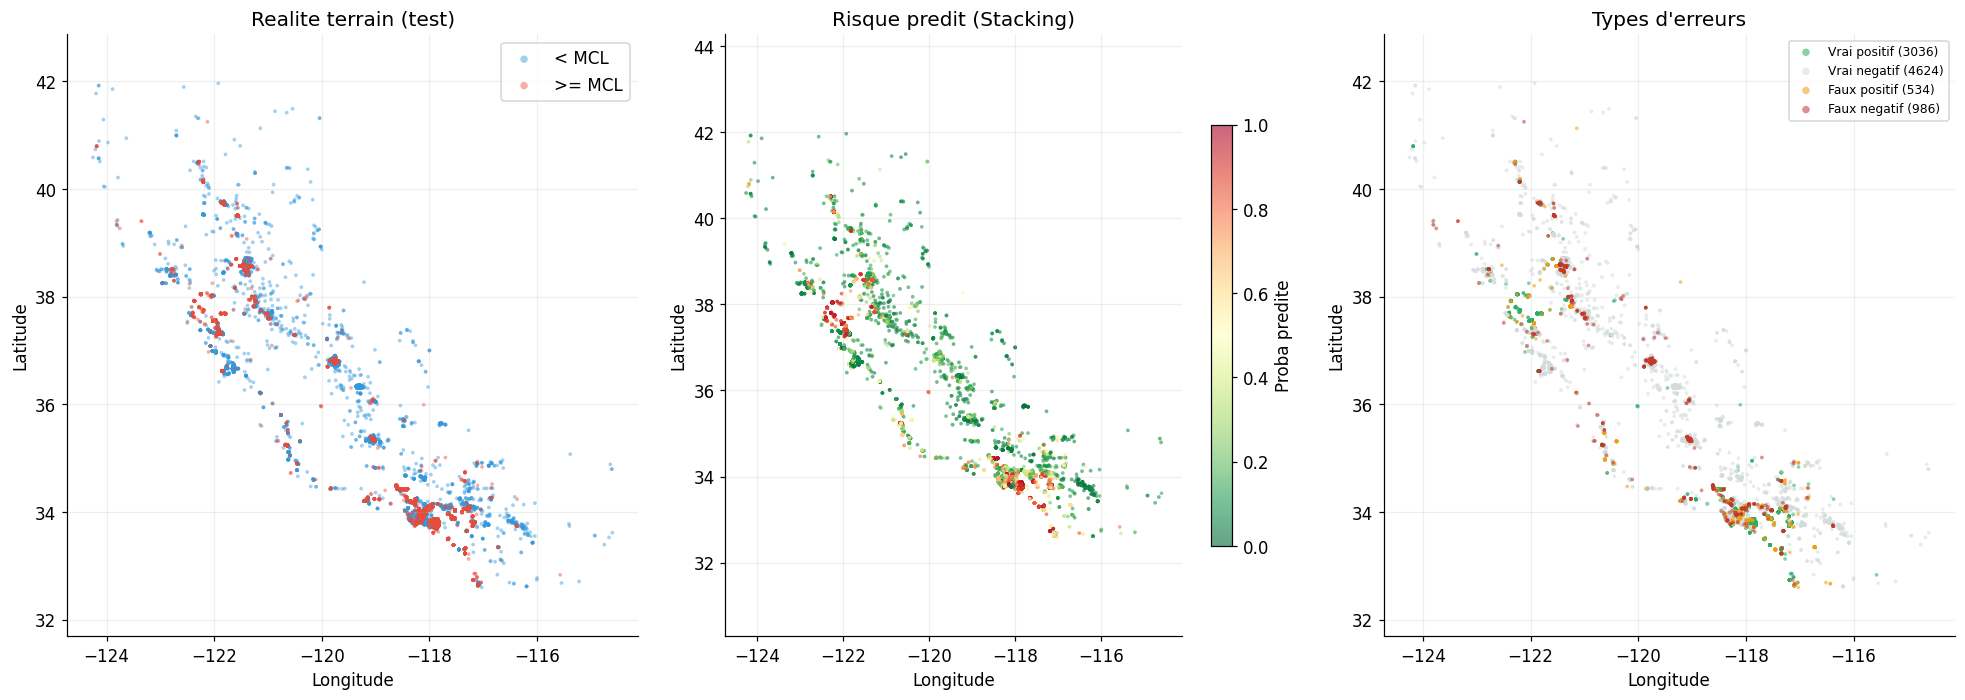

In [22]:
if {"latitude", "longitude"}.issubset(df.columns):
    coords = df.iloc[idx_test][["longitude", "latitude"]].copy()
    coords["y_true"] = y_test
    coords["proba"]  = RESULTS[best]["y_proba"]
    coords["y_pred"] = RESULTS[best]["y_pred"]
    fig, axes = plt.subplots(1, 3, figsize=(18, 6.5))
    for lab, c, mlab in [(0, "#3498db", "< MCL"), (1, "#e74c3c", ">= MCL")]:
        s = coords[coords.y_true == lab]
        axes[0].scatter(s.longitude, s.latitude, s=6, c=c, alpha=.45, label=mlab, edgecolors="none")
    axes[0].set_title("Realite terrain (test)"); axes[0].legend(markerscale=2)
    sc = axes[1].scatter(coords.longitude, coords.latitude, s=6, c=coords.proba,
                         cmap="RdYlGn_r", vmin=0, vmax=1, alpha=.6, edgecolors="none")
    plt.colorbar(sc, ax=axes[1], shrink=.7, label="Proba predite")
    axes[1].set_title(f"Risque predit ({best})")
    conds = [(coords.y_true==1)&(coords.y_pred==1), (coords.y_true==0)&(coords.y_pred==0),
             (coords.y_true==0)&(coords.y_pred==1), (coords.y_true==1)&(coords.y_pred==0)]
    labs = ["Vrai positif", "Vrai negatif", "Faux positif", "Faux negatif"]
    coords["err"] = np.select(conds, labs, default="?")
    pal = {"Vrai positif":"#27ae60","Vrai negatif":"#d5dbdb","Faux positif":"#f39c12","Faux negatif":"#c0392b"}
    for cat, c in pal.items():
        s = coords[coords.err == cat]
        axes[2].scatter(s.longitude, s.latitude, s=6, c=c, alpha=.55, label=f"{cat} ({len(s)})", edgecolors="none")
    axes[2].set_title("Types d'erreurs"); axes[2].legend(markerscale=2, fontsize=8)
    for ax in axes:
        ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude"); ax.set_aspect("equal", "datalim"); ax.grid(alpha=.2)
    plt.tight_layout(); savefig(fig, "fig14_map_predictions.png"); plt.show()

## Évaluation honnête — CV spatiale par blocs (optionnelle, `RUN_SPATIAL_CV=True`)

C'est l'évaluation qui compte pour le mémoire : hors-zone, la mémorisation géographique
disparaît et l'écart GNN/tabulaire peut s'inverser.

In [23]:
if RUN_SPATIAL_CV and {"latitude", "longitude"}.issubset(df.columns):
    yall = df["target"].values
    blocks = KMeans(SPATIAL_CV_K, random_state=RANDOM_STATE, n_init=10).fit_predict(
        StandardScaler().fit_transform(df[["latitude", "longitude"]].values))
    print("Tailles des blocs spatiaux :", np.bincount(blocks))
    rows = []
    for f in range(SPATIAL_CV_K):
        te = blocks == f; tr = ~te
        if te.sum() < 50 or len(np.unique(yall[te])) < 2:
            continue
        ct = ColumnTransformer([
            ("num", Pipeline([("im", SimpleImputer(strategy="median"))]), num_cols),
            ("cat", Pipeline([("im", SimpleImputer(strategy="constant", fill_value="Unknown")),
                              ("en", OrdinalEncoder(handle_unknown="use_encoded_value",
                                     unknown_value=-1, encoded_missing_value=-1))]), cat_cols)])
        Xtr, Xte = ct.fit_transform(df.loc[tr, feature_names]), ct.transform(df.loc[te, feature_names])
        ytr, yte = yall[tr], yall[te]
        spw = (ytr == 0).sum() / max(1, (ytr == 1).sum())
        for name_, mdl in [
            ("XGBoost", xgb.XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                subsample=0.8, colsample_bytree=0.8, scale_pos_weight=spw,
                tree_method="hist", random_state=RANDOM_STATE, eval_metric="logloss")),
            ("Random Forest", RandomForestClassifier(n_estimators=300, class_weight="balanced",
                n_jobs=-1, random_state=RANDOM_STATE))]:
            mdl.fit(Xtr, ytr); p = mdl.predict_proba(Xte)[:, 1]
            rows.append(dict(model=name_, fold=f, n_test=int(te.sum()),
                             prev=float(yte.mean()), AUC=roc_auc_score(yte, p),
                             AP=average_precision_score(yte, p)))
        print(f"  fold {f} ok (n_test={int(te.sum())}, prev={yte.mean():.2f})")
    cv_sp = pd.DataFrame(rows)
    cv_sp.to_csv(RES_DIR / "cv_spatiale.csv", index=False)
    print(cv_sp.groupby("model").agg(AUC_moy=("AUC", "mean"), AUC_std=("AUC", "std"),
                                     AP_moy=("AP", "mean")).round(4).to_string())
else:
    print("CV spatiale desactivee (RUN_SPATIAL_CV=False).")

Tailles des blocs spatiaux : [ 4886 15740  3411  6414  2637  3517  8037  1696]
  fold 0 ok (n_test=4886, prev=0.30)
  fold 1 ok (n_test=15740, prev=0.61)
  fold 2 ok (n_test=3411, prev=0.23)
  fold 3 ok (n_test=6414, prev=0.40)
  fold 4 ok (n_test=2637, prev=0.39)
  fold 5 ok (n_test=3517, prev=0.22)
  fold 6 ok (n_test=8037, prev=0.53)
  fold 7 ok (n_test=1696, prev=0.43)
               AUC_moy  AUC_std  AP_moy
model                                  
Random Forest   0.6335   0.0484  0.5279
XGBoost         0.6425   0.0473  0.5258


In [24]:
summary = {
    "notebook": "11 — HGT transductif (graphe unique + masques)",
    "target": "EPA 2024 NPDWR (MCL individuels + Indice de Risque melange)",
    "dataset": {"n_total": int(len(df)), "n_features": len(feature_names)},
    "split": {"mode": "group_by_well" if GROUP_SPLIT_BY_WELL else "random_stratified",
              "train": int(len(idx_train)), "val": int(len(idx_val)), "test": int(len(idx_test))},
    "config": {"OPTUNA_MODE": OPTUNA_MODE, "EPOCHS_HGT": EPOCHS_HGT,
               "KNN_SPATIAL_K": KNN_SPATIAL_K, "DROP_LOCATION": DROP_LOCATION,
               "hgt_best_params": bp if TORCH_GEOMETRIC_AVAILABLE else None},
    "results": {m: {k: round(float(v), 4) for k, v in RESULTS[m]["metrics"].items() if k != "name"}
                for m in RESULTS},
    "best_model_auc": best,
}
with open(RES_DIR / "synthese_resultats.json", "w") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

with open(MODELS_DIR / "random_forest.pkl", "wb") as f: pickle.dump(rf, f)
with open(MODELS_DIR / "xgboost.pkl", "wb") as f: pickle.dump(xgb_model, f)
with open(MODELS_DIR / "preprocessor.pkl", "wb") as f: pickle.dump(preprocessor, f)
with open(MODELS_DIR / "scaler.pkl", "wb") as f: pickle.dump(scaler, f)
if TORCH_GEOMETRIC_AVAILABLE:
    torch.save({"state_dict": hgt_model.state_dict(), "metadata": data.metadata(),
                "params": bp}, MODELS_DIR / "hgt_transductif.pt")
    with open(MODELS_DIR / "xgb_fusion.pkl", "wb") as f: pickle.dump(xgb_fusion, f)
    with open(MODELS_DIR / "meta_lr.pkl", "wb") as f: pickle.dump(meta_lr, f)
print("Artefacts sauvegardes dans", OUT_DIR.resolve())
print("Resultats :", json.dumps(summary["results"], indent=2, ensure_ascii=False))

zip_path = Path(f"PFAS_HGT_transductif_outputs_{time.strftime('%Y%m%d_%H%M')}.zip")
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for folder in (FIG_DIR, RES_DIR):
        for p in folder.rglob("*"):
            if p.is_file():
                zf.write(p, p.relative_to(OUT_DIR))
print(f"Archive creee : {zip_path}  ({zip_path.stat().st_size/1e6:.1f} Mo)")
if IN_COLAB:
    from google.colab import files
    files.download(str(zip_path))

Artefacts sauvegardes dans /content/outputs_notebook_transductif
Resultats : {
  "Random Forest": {
    "roc_auc": 0.891,
    "avg_precision": 0.8763,
    "accuracy": 0.8284,
    "balanced_accuracy": 0.8174,
    "precision": 0.8589,
    "recall": 0.728,
    "f1": 0.7881
  },
  "XGBoost": {
    "roc_auc": 0.9059,
    "avg_precision": 0.8911,
    "accuracy": 0.8332,
    "balanced_accuracy": 0.8245,
    "precision": 0.8484,
    "recall": 0.7541,
    "f1": 0.7985
  },
  "HGT transductif": {
    "roc_auc": 0.8425,
    "avg_precision": 0.8131,
    "accuracy": 0.7766,
    "balanced_accuracy": 0.7779,
    "precision": 0.7254,
    "recall": 0.7887,
    "f1": 0.7557
  },
  "Embedding Fusion": {
    "roc_auc": 0.8808,
    "avg_precision": 0.8657,
    "accuracy": 0.8168,
    "balanced_accuracy": 0.8097,
    "precision": 0.8149,
    "recall": 0.7529,
    "f1": 0.7826
  },
  "Stacking": {
    "roc_auc": 0.9061,
    "avg_precision": 0.8899,
    "accuracy": 0.8344,
    "balanced_accuracy": 0.8257,
   

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>